In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc

from scipy.interpolate import interp1d,CubicSpline
from scipy.optimize import curve_fit

rc("lines", linewidth=2)
rc("font", size=18)

_dpi = 200

In [5]:
data = pd.read_excel("Data-2025-2026.ods", sheet_name = 'Sheet1')

In [6]:
data

,Ug,I [A],I [mA],Up [V],UR [V],Um [V],Ug [V]
0,8.00,-0.31529,-315.29,0.885200,3.5604,3.5604,8.006000
1,7.50,-0.29440,-294.40,0.824270,3.3422,3.3390,7.505470
2,7.00,-0.26984,-269.84,0.759450,3.1238,3.1201,7.003350
3,6.50,-0.24841,-248.41,0.709700,2.8971,2.8957,6.502500
4,6.00,-0.22578,-225.78,0.651400,2.6768,2.6763,6.004500
5,5.50,-0.20299,-202.99,0.593000,2.4579,2.4560,5.506900
6,5.00,-0.17980,-179.80,0.533450,2.2360,2.2358,5.005250
7,4.50,-0.15672,-156.72,0.471400,2.0175,2.0148,4.503700
8,4.00,-0.13396,-133.96,0.421380,1.7876,1.7960,4.004980
9,3.50,-0.11085,-110.85,0.359040,1.5748,1.5750,3.508840


NameError: name 'P' is not defined

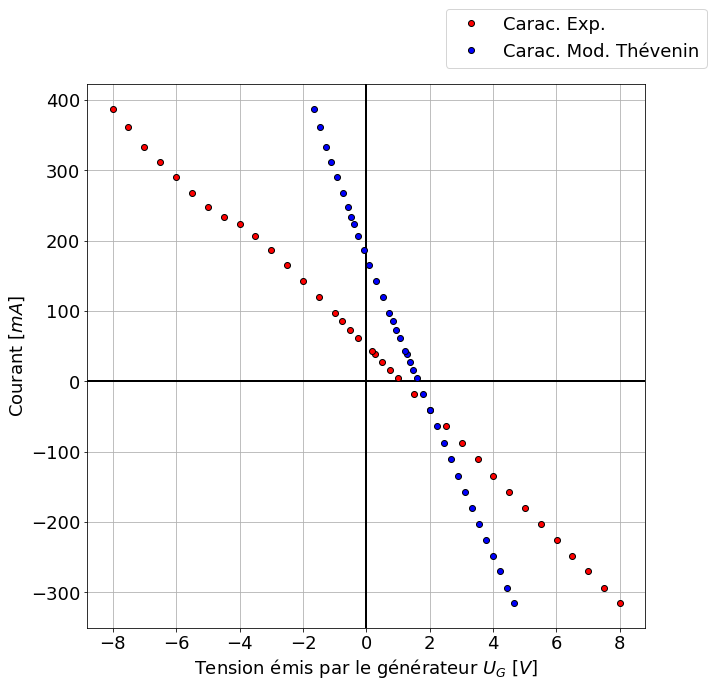

In [15]:
def I_fit(U, G = 0) : 
    return - G*U



fig = plt.figure(figsize=(10,10))
ax = fig.subplots()

Ug = data['UR [V]'] + data['Um [V]'] + data['Up [V]']
Ug = data['Ug [V]']

#P = np.poly1d(np.polyfit(data['UR [V]'], -data['I [mA]'], deg = 1))
#fit = curve_fit(I_fit, data['UR [V]'], -data['I [mA]'])
#print(fit)

ax.errorbar(Ug, data['I [mA]'], color = 'red', marker = 'o', markeredgecolor = 'black', ecolor='black', elinewidth = 2, ls = 'none', label = 'Carac. Exp.') #, xerr = data['dUg [V]'], yerr = data['dI [mA]']
ax.errorbar(data['UR [V]']+1.1, data['I [mA]'], color = 'blue', marker = 'o', markeredgecolor = 'black', ecolor='black', elinewidth = 2, ls = 'none', label = 'Carac. Mod. Thévenin') # xerr = data['dUR [V]'], yerr = data['dI [mA]'], 
#ax.plot(data['UR [V]']+1.1, P(data['UR [V]']), label = 'Linear Regression', color = 'blue')
#ax.plot(data['UR [V]']+1.1, I_fit(data['UR [V]'], G=fit[0]), label = 'Linear Regression', color = 'blue')

ax.axhline(y= 0, color = 'black')
ax.axvline(x = 0, color = 'black')

ax.set_xlabel("Tension émis par le générateur $U_G$ [$V$]")
ax.set_ylabel("Courant [$mA$]")

ax.grid()

fig.legend()

#fig.savefig("Graph01.pdf", dpi = _dpi)

print(P)

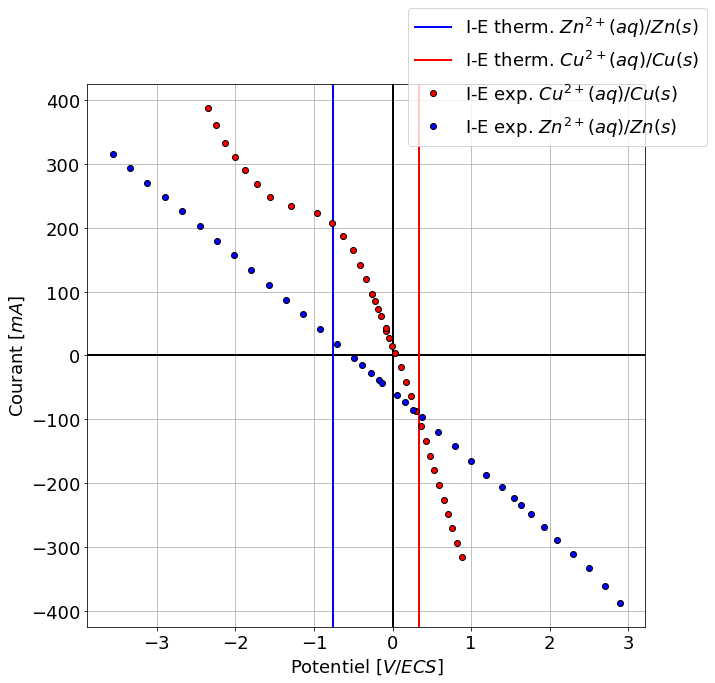

In [19]:
fig = plt.figure(figsize=(10,10))
ax = fig.subplots()

ax.errorbar(data['Up [V]'], data['I [mA]'], color = 'red', marker = 'o', markeredgecolor = 'black', ecolor='black', elinewidth = 2, ls = 'none', label = "I-E exp. $Cu^{2+} (aq) / Cu(s)$")
#, xerr = data['dUp [V]'], yerr = data['dI [mA]']
ax.errorbar(-data['Um [V]'], -data['I [mA]'], color = 'blue', marker = 'o', markeredgecolor = 'black', ecolor='black', elinewidth = 2, ls = 'none', label = "I-E exp. $Zn^{2+} (aq) / Zn (s)$")
#, xerr = data['dUm [V]'], yerr = data['dI [mA]']

ax.axhline(y= 0, color = 'black')
ax.axvline(x = 0, color = 'black')

ax.axvline(x=-0.76, color = 'blue', label = 'I-E therm. $Zn^{2+} (aq) / Zn (s)$') #-1.04,
ax.axvline(x=0.34, color = 'red', label = 'I-E therm. $Cu^{2+} (aq) / Cu(s)$') # 0.06

ax.set_xlabel("Potentiel [$V/ECS$]")
ax.set_ylabel("Courant [$mA$]")

ax.grid()

fig.legend()

#fig.savefig("Graph02.pdf", dpi = _dpi)